In [10]:
# import statements
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [11]:
df = pd.read_csv("../data/raw/synthetic_house_prices_20_years.csv")
df.head()

,Neighborhood,Year,Season,Property Type,Bedrooms,Bathrooms,Year Built,Renovation Year,Garage Type,Square Footage (House),Square Footage (Land),Basement,Legal Units,Market Price
0,Kitsilano,2004,Spring,Triplex,1,3,1954,2000.0,Double,1308,6742,Not Finished,2,1734587.40
1,Kitsilano,2004,Summer,Condo,3,1,2022,NaN,Single,3947,2592,Finished,0,951731.62
2,Kitsilano,2004,Fall,House,4,1,2006,NaN,NaN,919,9519,Not Finished,2,1782016.80
3,Kitsilano,2004,Winter,Condo,2,2,1960,NaN,Triple,2352,1555,Not Finished,2,335768.06
4,Kitsilano,2005,Spring,Duplex,5,2,1960,1992.0,NaN,2474,7031,Not Finished,0,1571528.42


In [12]:
df.describe()

,Year,Bedrooms,Bathrooms,Year Built,Renovation Year,Square Footage (House),Square Footage (Land),Legal Units,Market Price
count,3520.000000,3520.000000,3520.000000,3520.000000,1503.000000,3520.000000,3520.000000,3520.000000,3.520000e+03
mean,2013.500000,2.951989,1.979545,1986.206818,2007.276114,2741.978125,5574.964205,0.990909,2.205096e+06
std,5.767101,1.416310,0.823174,21.358038,14.180509,1293.928715,2609.557714,0.822687,1.252980e+06
min,2004.000000,1.000000,1.000000,1950.000000,1962.000000,505.000000,1000.000000,0.000000,3.111203e+05
25%,2008.750000,2.000000,1.000000,1968.000000,1998.000000,1629.250000,3383.000000,0.000000,1.259841e+06
50%,2013.500000,3.000000,2.000000,1986.000000,2012.000000,2722.000000,5559.500000,1.000000,1.945505e+06
75%,2018.250000,4.000000,3.000000,2005.000000,2019.000000,3880.250000,7856.000000,2.000000,2.865002e+06
max,2023.000000,5.000000,3.000000,2023.000000,2023.000000,4999.000000,9997.000000,2.000000,9.461201e+06


In [13]:
df.isnull().sum()

Neighborhood                 0
Year                         0
Season                       0
Property Type                0
Bedrooms                     0
Bathrooms                    0
Year Built                   0
Renovation Year           2017
Garage Type                946
Square Footage (House)       0
Square Footage (Land)        0
Basement                     0
Legal Units                  0
Market Price                 0
dtype: int64

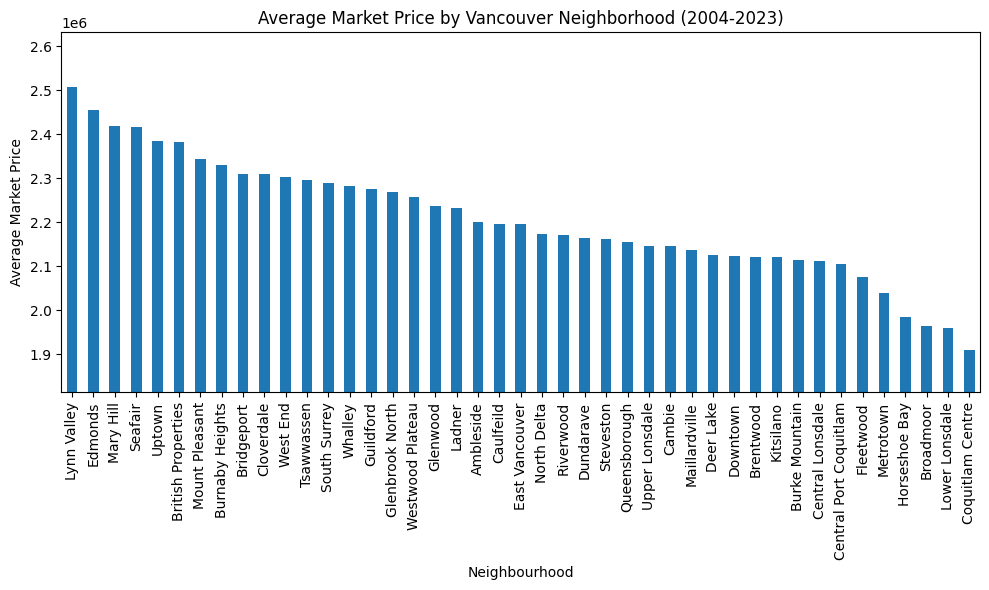

In [14]:
neighborhood_avg_mkt_prc = (
    df
    .groupby("Neighborhood")["Market Price"]
    .mean()
    .sort_values(ascending=False)
)

min_val = neighborhood_avg_mkt_prc.min()
max_val = neighborhood_avg_mkt_prc.max()

ax = neighborhood_avg_mkt_prc.plot(kind="bar", figsize=(10,6))
ax.set_ylim(min_val * 0.95, max_val * 1.05)
plt.title("Average Market Price by Vancouver Neighborhood (2004-2023)")
plt.ylabel("Average Market Price")
plt.xlabel("Neighbourhood")
plt.tight_layout()
plt.savefig("../reports/fig_neighborhood_avg_mkt_prc")
plt.show()

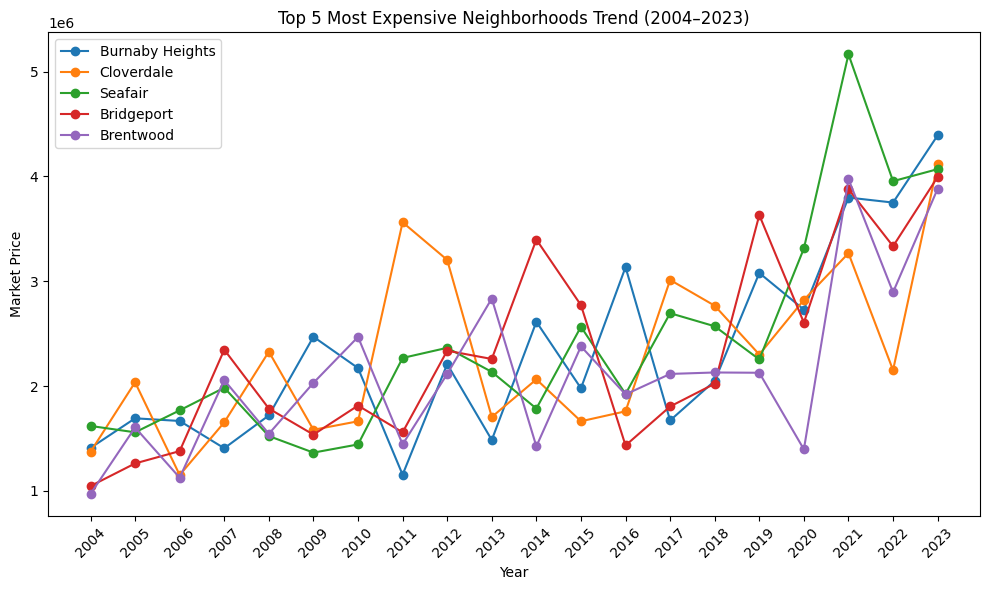

In [15]:
housing_year = (
    df
    .groupby(["Year", "Neighborhood"])["Market Price"]
    .mean()
    .reset_index()
)
housing_data_pivot = housing_year.pivot(
    index="Year",
    columns="Neighborhood",
    values="Market Price"
)
latest_year = housing_data_pivot.index.max()

top5 = (
    housing_data_pivot.loc[latest_year]
    .sort_values(ascending=False)
    .head(5)
    .index
)

top5_data = housing_data_pivot[top5]
plt.figure(figsize=(10,6))

for col in top5_data.columns:
    plt.plot(top5_data.index, top5_data[col], marker="o", label=col)

plt.title("Top 5 Most Expensive Neighborhoods Trend (2004–2023)")
plt.ylabel("Market Price")
plt.xlabel("Year")
plt.xticks(top5_data.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("../reports/fig_mkt_prc_trend")
plt.show()

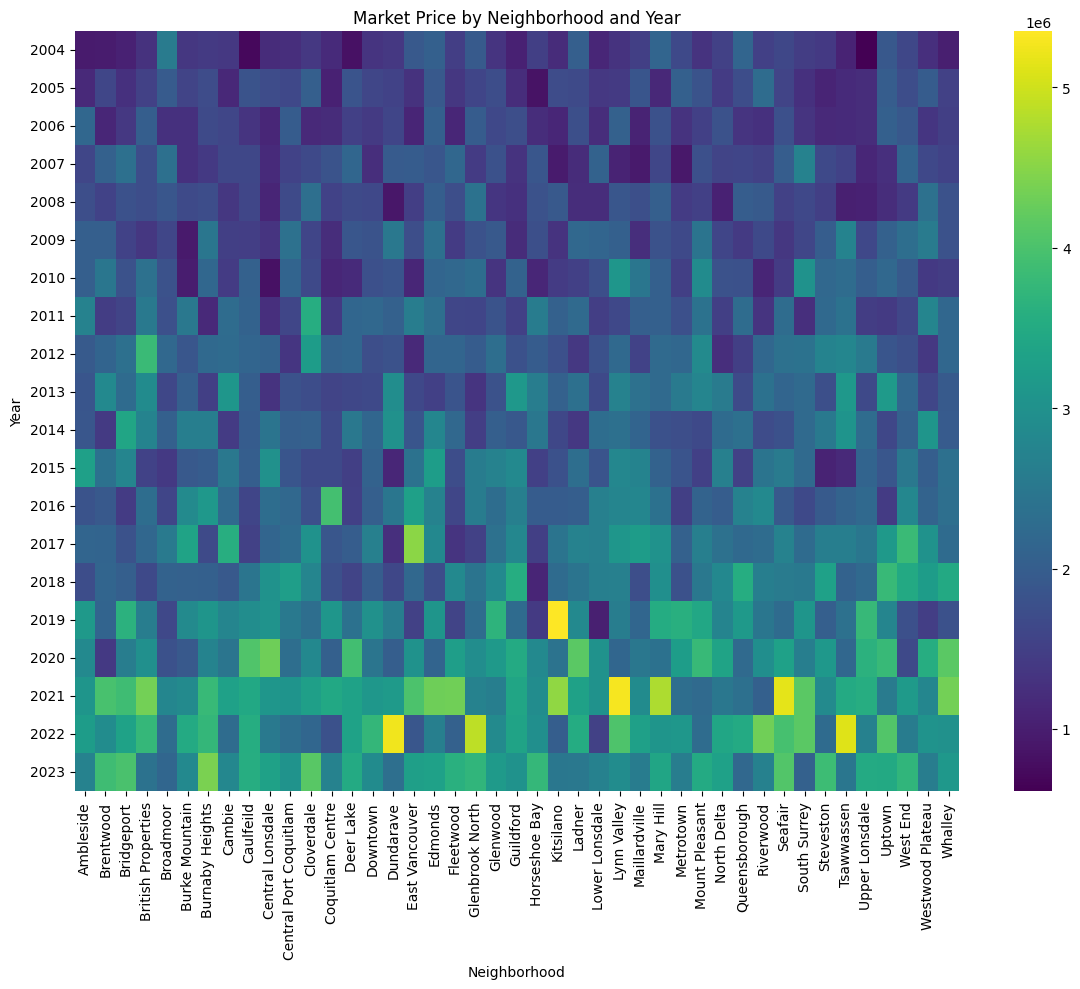

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(housing_data_pivot, cmap="viridis")
plt.title("Market Price by Neighborhood and Year")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/fig_mkt_prc_heatmap")
plt.show()

In [17]:
coord = pd.read_csv("../data/raw/vancouver_neighborhoods_coordinates.csv")
housing_coord = pd.merge(housing_year, coord, how="inner", on=["Neighborhood"])
housing_coord.head()

,Year,Neighborhood,Market Price,City,Latitude,Longitude
0,2004,Ambleside,9.526481e+05,West Vancouver,49.3281,-123.1512
1,2004,Brentwood,9.710210e+05,Burnaby,49.2765,-123.0076
2,2004,Bridgeport,1.046080e+06,Richmond,49.1950,-123.1014
3,2004,British Properties,1.280887e+06,West Vancouver,49.3425,-123.1479
4,2004,Broadmoor,2.572252e+06,Richmond,49.1414,-123.1338


In [18]:
fig = px.scatter_mapbox(
    housing_coord[housing_coord["Year"]==latest_year],
    lat="Latitude",
    lon="Longitude",
    size="Market Price",          # Bubble size
    color="Market Price",         # Bubble color
    hover_name="Neighborhood",
    hover_data={"Market Price": ":,.0f"},
    size_max=50,
    zoom=11,   
    mapbox_style="carto-positron"
)

fig.update_layout(
    title=f"Vancouver Market Prices by Neighborhood ({latest_year})"
)
fig.write_html("../reports/fig_van_market_map.html")
fig.show()

<positron-console-cell-18>:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

